# Wildfire Classification with CLIP - Zero-Shot vs Prompt Tuning

**Idea:** Take CLIP (a pretrained vision-language model), evaluate its zero-shot performance on wildfire vs. no-wildfire images, then improve it using prompt tuning instead of retraining the entire model.

**Dataset:** The Wildfire Dataset (Kaggle: elmadafri/the-wildfire-dataset), containing aerial images labeled as wildfire and no wildfire.

#Dataset



In [1]:
import kagglehub

path = kagglehub.dataset_download("elmadafri/the-wildfire-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'the-wildfire-dataset' dataset.
Path to dataset files: /kaggle/input/the-wildfire-dataset


In [2]:
import os

print(os.listdir(path))

['the_wildfire_dataset_2n_version']


In [3]:
import os

dataset_path = os.path.join(path, "the_wildfire_dataset_2n_version")

print(os.listdir(dataset_path))

['val', 'test', 'train']


In [4]:
train_path = f"{dataset_path}/train"
val_path = f"{dataset_path}/val"
test_path = f"{dataset_path}/test"

import os

print("Train:", os.listdir(train_path))
print("Validation:", os.listdir(val_path))
print("Test:", os.listdir(test_path))

Train: ['nofire', 'fire']
Validation: ['nofire', 'fire']
Test: ['nofire', 'fire']


In [5]:
import os

dataset_root = os.path.join(path, "the_wildfire_dataset_2n_version")

train_dir = os.path.join(dataset_root, "train")
val_dir = os.path.join(dataset_root, "val")
test_dir = os.path.join(dataset_root, "test")

print("Train:", os.listdir(train_dir))
print("Validation:", os.listdir(val_dir))
print("Test:", os.listdir(test_dir))

Train: ['nofire', 'fire']
Validation: ['nofire', 'fire']
Test: ['nofire', 'fire']


In [6]:
!pip install -q transformers torch torchvision kagglehub matplotlib scikit-learn

import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


In [7]:
import os

for root, dirs, files in os.walk(dataset_path):
    depth = root.replace(dataset_path, "").count(os.sep)
    if depth <= 2:
        print("  " * depth + os.path.basename(root) + "/")

the_wildfire_dataset_2n_version/
  val/
    nofire/
    fire/
  test/
    nofire/
    fire/
  train/
    nofire/
    fire/


In [8]:
from pathlib import Path
import random

exts = {".jpg", ".jpeg", ".png"}

all_images = []

for p in Path(dataset_root).rglob("*"):
    if p.suffix.lower() in exts:
        all_images.append((str(p), p.parent.name))

labels_found = sorted(set(label for _, label in all_images))

print(f"Total Images: {len(all_images)}")
print("Labels Found:", labels_found)

for img_path, label in random.sample(all_images, 5):
    print(label, "->", img_path)

Total Images: 2699
Labels Found: ['fire', 'nofire']
nofire -> /kaggle/input/the-wildfire-dataset/the_wildfire_dataset_2n_version/train/nofire/cassie-matias-l8Ab2-Tgvgk-unsplash.jpg
nofire -> /kaggle/input/the-wildfire-dataset/the_wildfire_dataset_2n_version/test/nofire/kym-mackinnon-mT8BWsYyeU0-unsplash.jpg
fire -> /kaggle/input/the-wildfire-dataset/the_wildfire_dataset_2n_version/train/fire/51234131611_f593a97b57_o.jpg
nofire -> /kaggle/input/the-wildfire-dataset/the_wildfire_dataset_2n_version/train/nofire/nathan-queloz-USuDsWIPgNA-unsplash.jpg
nofire -> /kaggle/input/the-wildfire-dataset/the_wildfire_dataset_2n_version/test/nofire/neven-krcmarek-50HS3AzJsvQ-unsplash.jpg


## Create a Small Balanced Training and Test Subset

In [9]:
classnames = labels_found

# Small balanced subset for fast experiments
n_train = 60
n_test = 40

by_class = {c: [p for p, l in all_images if l == c] for c in classnames}

random.seed(42)

for c in classnames:
    random.shuffle(by_class[c])

train_set, test_set = [], []

for c in classnames:
    train_set += [(p, c) for p in by_class[c][:n_train]]
    test_set += [(p, c) for p in by_class[c][n_train:n_train + n_test]]

random.shuffle(train_set)
random.shuffle(test_set)

print(f"Training Images: {len(train_set)}")
print(f"Testing Images: {len(test_set)}")

Training Images: 120
Testing Images: 80


## Visualize Sample Training Images

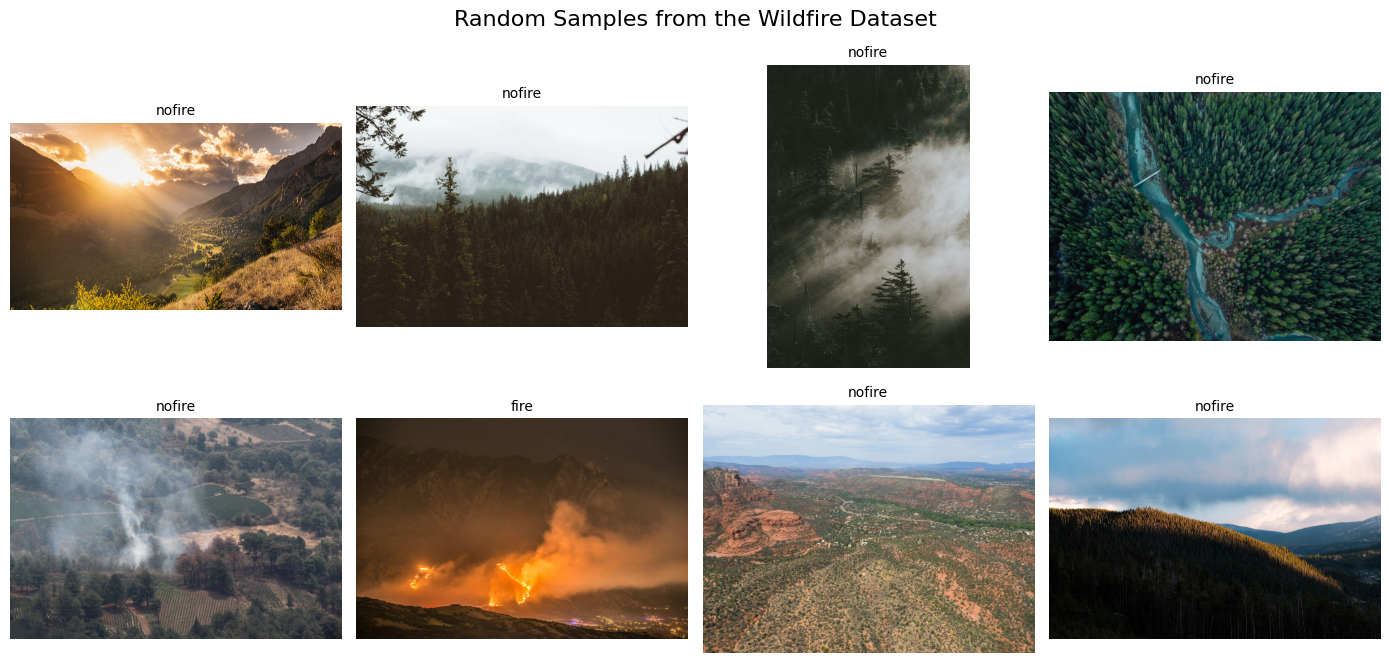

In [10]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
plt.suptitle("Random Samples from the Wildfire Dataset", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])

for ax, (path, label) in zip(axes.flat, random.sample(train_set, 8)):
    ax.imshow(Image.open(path).convert("RGB"))
    ax.set_title(label, fontsize=10)
    ax.axis("off")

plt.tight_layout()

plt.savefig("fig_sample_images.png", dpi=300, bbox_inches="tight")

plt.show()

In [25]:
from google.colab import files

files.download("fig_sample_images.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Load the Pretrained CLIP Model

I use the pretrained CLIP (ViT-B/32) model from OpenAI as the backbone for this project. Both the image encoder and text encoder are kept frozen throughout the experiment. This allows us to evaluate the original zero-shot performance and later adapt the model by learning only a small set of prompt parameters.

In [12]:
from transformers import CLIPModel, CLIPProcessor, CLIPTokenizer
import torch

# Pretrained CLIP model
model_name = "openai/clip-vit-base-patch32"

# Use GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# Load model and processor
clip_model = CLIPModel.from_pretrained(model_name).to(device)
processor = CLIPProcessor.from_pretrained(model_name)
tokenizer = CLIPTokenizer.from_pretrained(model_name)

# Freeze all CLIP parameters
for param in clip_model.parameters():
    param.requires_grad = False

print("CLIP model loaded successfully.")

Device: cuda


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP model loaded successfully.


## Zero-Shot Classification with CLIP

Before adapting the model, I evaluate the original zero-shot performance of CLIP.

For each class, I define a simple natural-language prompt and ask CLIP which prompt best matches each image. No model parameters are updated in this stage. This serves as the baseline that the prompt-tuned model will later be compared against.

In [13]:
text_inputs = processor(
    text=["a photo of a wildfire"],
    return_tensors="pt",
    padding=True
).to(device)

output = clip_model.get_text_features(**text_inputs)

print(type(output))

<class 'transformers.modeling_outputs.BaseModelOutputWithPooling'>


In [14]:
import transformers
print(transformers.__version__)

5.13.1


In [15]:
import inspect
import transformers

print("Transformers:", transformers.__version__)
print(inspect.signature(clip_model.get_text_features))
print(inspect.signature(clip_model.get_image_features))

Transformers: 5.13.1
(input_ids: torch.Tensor, attention_mask: torch.Tensor | None = None, position_ids: torch.Tensor | None = None, **kwargs: Unpack[transformers.utils.generic.TransformersKwargs]) -> tuple | transformers.modeling_outputs.BaseModelOutputWithPooling
(pixel_values: torch.FloatTensor, interpolate_pos_encoding: bool = False, **kwargs: Unpack[transformers.utils.generic.TransformersKwargs]) -> tuple | transformers.modeling_outputs.BaseModelOutputWithPooling


In [16]:
text_inputs = processor(
    text=["a photo of a wildfire"],
    return_tensors="pt",
    padding=True
).to(device)

out = clip_model.get_text_features(**text_inputs)

print(type(out))
print(out)

<class 'transformers.modeling_outputs.BaseModelOutputWithPooling'>
BaseModelOutputWithPooling(last_hidden_state=tensor([[[ 0.3393,  0.1165,  0.1020,  ...,  0.2468,  0.5906,  0.1013],
         [ 1.9753, -0.5844,  0.3685,  ...,  1.1658,  0.8050, -0.9801],
         [ 1.0580, -0.9600,  1.0018,  ..., -0.5155, -0.1437, -1.9444],
         ...,
         [ 0.3059, -1.5037, -0.4022,  ..., -0.0224,  0.9105, -0.3916],
         [ 0.7582, -0.1433,  0.4176,  ...,  1.0664,  1.5333, -0.4438],
         [ 0.0135, -0.0228,  1.0432,  ...,  1.2181,  1.3634,  0.1722]]],
       device='cuda:0'), pooler_output=tensor([[ 7.7526e-02, -2.9388e-01,  2.4732e-01, -1.7291e-01,  1.1083e-01,
          1.0869e-01, -4.4956e-01, -5.9114e-01, -1.4836e-01,  2.1115e-02,
          1.4794e-01, -7.4855e-01, -2.0968e-01, -9.8435e-02, -3.8396e-02,
         -4.8664e-02,  3.0509e-01,  1.1603e-01,  9.6582e-02, -3.4579e-02,
          5.9520e-01,  2.3912e-01,  3.6393e-01,  9.6767e-02, -1.8597e-01,
         -1.7201e-02,  1.8080e-01,  1

In [17]:
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report

# Natural language prompts
hand_prompts = {}

for c in classnames:
    is_fire = "fire" in c.lower() and "no" not in c.lower()
    hand_prompts[c] = (
        "a photo of a wildfire"
        if is_fire
        else "a photo of a landscape with no wildfire"
    )

print(hand_prompts)


# Zero-shot prediction
@torch.no_grad()
def zero_shot_predict(paths, prompts):

    classes = list(prompts.keys())

    # ----- Text embeddings -----
    text_inputs = processor(
        text=list(prompts.values()),
        return_tensors="pt",
        padding=True
    ).to(device)

    text_outputs = clip_model.get_text_features(**text_inputs)

    # New Transformers compatibility
    if hasattr(text_outputs, "pooler_output"):
        text_features = text_outputs.pooler_output
    else:
        text_features = text_outputs

    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

    predictions = []

    # ----- Image embeddings -----
    for i in range(0, len(paths), 32):

        batch = paths[i:i+32]

        images = [
            Image.open(p).convert("RGB")
            for p in batch
        ]

        image_inputs = processor(
            images=images,
            return_tensors="pt"
        ).to(device)

        image_outputs = clip_model.get_image_features(**image_inputs)

        if hasattr(image_outputs, "pooler_output"):
            image_features = image_outputs.pooler_output
        else:
            image_features = image_outputs

        image_features = image_features / image_features.norm(
            dim=-1,
            keepdim=True
        )

        similarity = image_features @ text_features.T

        predictions.extend(
            [classes[idx] for idx in similarity.argmax(dim=-1).cpu().tolist()]
        )

    return predictions


# Evaluate
test_paths = [p for p, _ in test_set]
test_labels = [l for _, l in test_set]

zero_shot_preds = zero_shot_predict(
    test_paths,
    hand_prompts
)

zero_shot_acc = accuracy_score(
    test_labels,
    zero_shot_preds
)

print(f"\nZero-shot Accuracy: {zero_shot_acc:.4f}\n")

print(
    classification_report(
        test_labels,
        zero_shot_preds
    )
)

{'fire': 'a photo of a wildfire', 'nofire': 'a photo of a landscape with no wildfire'}


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (96631920 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(



Zero-shot Accuracy: 0.9375

              precision    recall  f1-score   support

        fire       1.00      0.88      0.93        40
      nofire       0.89      1.00      0.94        40

    accuracy                           0.94        80
   macro avg       0.94      0.94      0.94        80
weighted avg       0.94      0.94      0.94        80



## Zero-Shot Confusion Matrix

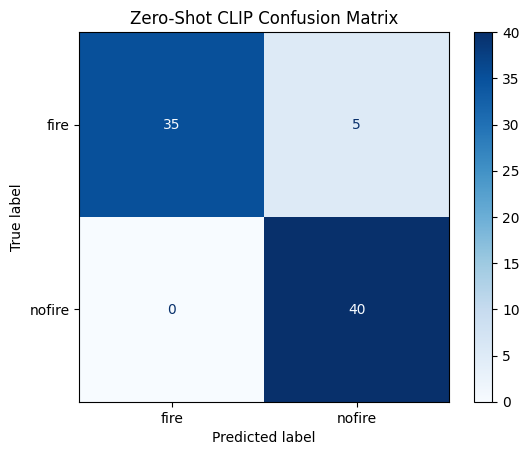

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay.from_predictions(
    test_labels,
    zero_shot_preds,
    cmap="Blues"
)

plt.title("Zero-Shot CLIP Confusion Matrix")
plt.savefig(
    "fig_zero_shot_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
from google.colab import files

files.download("fig_zero_shot_confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Prompt Tuning Setup

I introduce a small set of learnable context vectors that are optimized during training while keeping the entire CLIP backbone frozen.

In [20]:
import torch.nn as nn

# Number of learnable context vectors
n_ctx = 8

# CLIP text embeddings
tok_embed = clip_model.text_model.embeddings.token_embedding
pos_embed = clip_model.text_model.embeddings.position_embedding

# Embedding dimension
dim = tok_embed.embedding_dim

# Maximum sequence length
max_len = pos_embed.num_embeddings

# Special tokens
bos_id = tokenizer.bos_token_id
eos_id = tokenizer.eos_token_id

# Learnable prompt vectors
ctx = nn.Parameter(
    torch.empty(n_ctx, dim, device=device)
)

nn.init.normal_(ctx, std=0.02)

print(
    f"Learnable Parameters: {ctx.numel():,}"
)

print(
    f"Frozen CLIP Parameters: {sum(p.numel() for p in clip_model.parameters()):,}"
)

Learnable Parameters: 4,096
Frozen CLIP Parameters: 151,277,313


In [21]:
def build_prompts(names, ctx):
    embeds, eot_pos = [], []
    for name in names:
        ids = tokenizer(name.replace("_", " "), add_special_tokens=False)["input_ids"]
        name_emb = tok_embed(torch.tensor(ids, device=device))
        bos_emb = tok_embed(torch.tensor([bos_id], device=device))
        eos_emb = tok_embed(torch.tensor([eos_id], device=device))

        seq = torch.cat([bos_emb, ctx, name_emb, eos_emb], dim=0)
        eot_pos.append(seq.shape[0] - 1)

        pad = max_len - seq.shape[0]
        if pad > 0:
            seq = torch.cat([seq, torch.zeros(pad, dim, device=device)], dim=0)
        embeds.append(seq)

    x = torch.stack(embeds)
    positions = torch.arange(x.shape[1], device=device).unsqueeze(0)
    x = x + pos_embed(positions)
    return x, torch.tensor(eot_pos, device=device)


def encode_text_learned(names, ctx):
    x, eot_pos = build_prompts(names, ctx)
    L = x.shape[1]
    causal = torch.triu(torch.full((L, L), float("-inf"), device=device), diagonal=1)
    causal = causal.unsqueeze(0).unsqueeze(0)

    out = clip_model.text_model.encoder(inputs_embeds=x, attention_mask=None, causal_attention_mask=causal)
    h = clip_model.text_model.final_layer_norm(out[0])
    pooled = h[torch.arange(h.shape[0]), eot_pos]
    return clip_model.text_projection(pooled)

# quick check, should just print a shape and not blow up
print(encode_text_learned(classnames, ctx).shape)


torch.Size([2, 512])


In [26]:
print("ctx:", "ctx" in globals())
print("loader:", "loader" in globals())
print("n_epochs:", "n_epochs" in globals())
print("optimizer:", "optimizer" in globals())
print("clip_model:", "clip_model" in globals())
print("processor:", "processor" in globals())

ctx: True
loader: False
n_epochs: False
optimizer: False
clip_model: True
processor: True


In [27]:
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

# Dataset
class WFDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        pixel_values = processor(
            images=Image.open(path).convert("RGB"),
            return_tensors="pt"
        )["pixel_values"][0]

        return pixel_values, classnames.index(label)

# DataLoader
loader = DataLoader(
    WFDataset(train_set),
    batch_size=16,
    shuffle=True
)

# Optimizer
optimizer = optim.AdamW([ctx], lr=0.002)

# Training settings
n_epochs = 15
loss_history = []

print("Training setup complete!")

Training setup complete!


In [28]:
for epoch in range(n_epochs):

    epoch_losses = []

    for pixel_values, labels in loader:

        pixel_values = pixel_values.to(device)
        labels = labels.to(device)

        # Frozen CLIP image encoder
        with torch.no_grad():

            image_features = clip_model.get_image_features(
                pixel_values=pixel_values
            )

            # Transformers 5.x fix
            if hasattr(image_features, "pooler_output"):
                image_features = image_features.pooler_output

            image_features = image_features / image_features.norm(
                dim=-1,
                keepdim=True
            )

        # Learnable prompt features
        text_features = encode_text_learned(classnames, ctx)

        text_features = text_features / text_features.norm(
            dim=-1,
            keepdim=True
        )

        # CLIP similarity
        logit_scale = clip_model.logit_scale.exp()

        logits = logit_scale * image_features @ text_features.T

        loss = nn.functional.cross_entropy(logits, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        epoch_losses.append(loss.item())

    avg_loss = sum(epoch_losses) / len(epoch_losses)

    loss_history.append(avg_loss)

    print(f"Epoch {epoch+1:02d}/{n_epochs} | Loss = {avg_loss:.4f}")

Epoch 01/15 | Loss = 0.6396
Epoch 02/15 | Loss = 0.3956
Epoch 03/15 | Loss = 0.1867
Epoch 04/15 | Loss = 0.1509
Epoch 05/15 | Loss = 0.1365
Epoch 06/15 | Loss = 0.0988
Epoch 07/15 | Loss = 0.0685
Epoch 08/15 | Loss = 0.0527
Epoch 09/15 | Loss = 0.0330
Epoch 10/15 | Loss = 0.0233
Epoch 11/15 | Loss = 0.0204
Epoch 12/15 | Loss = 0.0122
Epoch 13/15 | Loss = 0.0104
Epoch 14/15 | Loss = 0.0103
Epoch 15/15 | Loss = 0.0093


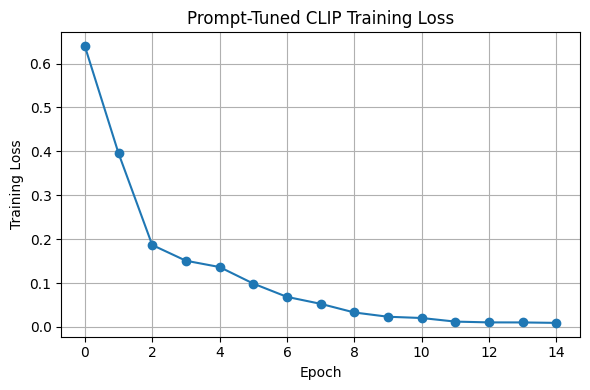

In [29]:
# Figure: Prompt-Tuned CLIP Training Loss

plt.figure(figsize=(6,4))

plt.plot(
    range(1, n_epochs + 1),
    loss_history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Prompt-Tuned CLIP Training Loss")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "fig_prompt_tuned_training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
from google.colab import files
files.download("fig_prompt_tuned_training_loss.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
print("encode_text_learned:", "encode_text_learned" in globals())
print("ctx:", "ctx" in globals())
print("classnames:", "classnames" in globals())
print("test_paths:", "test_paths" in globals())

encode_text_learned: True
ctx: True
classnames: True
test_paths: True


In [35]:
from PIL import Image
import torch

@torch.no_grad()
def learned_predict(paths):

    txt_feat = encode_text_learned(classnames, ctx)
    txt_feat = txt_feat / txt_feat.norm(dim=-1, keepdim=True)

    preds = []

    for i in range(0, len(paths), 32):

        batch = paths[i:i+32]

        imgs = [Image.open(p).convert("RGB") for p in batch]

        img_in = processor(
            images=imgs,
            return_tensors="pt"
        ).to(device)

        img_feat = clip_model.get_image_features(**img_in)

        # Transformers 5.x fix
        if hasattr(img_feat, "pooler_output"):
            img_feat = img_feat.pooler_output

        img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)

        sim = img_feat @ txt_feat.T

        preds += [
            classnames[idx]
            for idx in sim.argmax(dim=-1).cpu().tolist()
        ]

    return preds

In [36]:
tuned_preds = learned_predict(test_paths)

from sklearn.metrics import accuracy_score, classification_report

tuned_acc = accuracy_score(test_labels, tuned_preds)

print("Zero-shot Accuracy :", zero_shot_acc)
print("Prompt-Tuned Accuracy :", tuned_acc)

print(classification_report(test_labels, tuned_preds))

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (96631920 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Zero-shot Accuracy : 0.9375
Prompt-Tuned Accuracy : 0.975
              precision    recall  f1-score   support

        fire       1.00      0.95      0.97        40
      nofire       0.95      1.00      0.98        40

    accuracy                           0.97        80
   macro avg       0.98      0.97      0.97        80
weighted avg       0.98      0.97      0.97        80



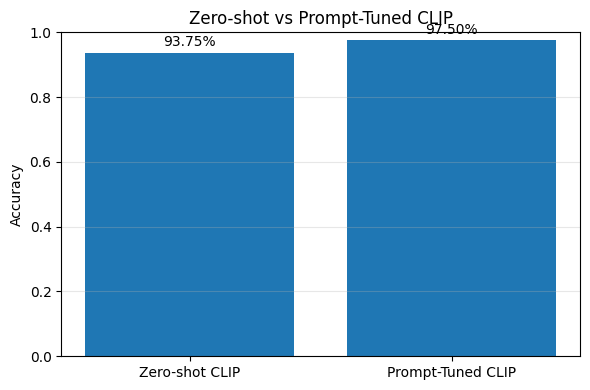

In [38]:
# Figure: Accuracy Comparison

plt.figure(figsize=(6,4))

bars = plt.bar(
    ["Zero-shot CLIP", "Prompt-Tuned CLIP"],
    [zero_shot_acc, tuned_acc]
)

plt.ylim(0, 1.0)

plt.ylabel("Accuracy")
plt.title("Zero-shot vs Prompt-Tuned CLIP")

# Accuracy labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f"{bar.get_height()*100:.2f}%",
        ha="center",
        fontsize=10
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "fig_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [39]:
from google.colab import files
files.download("fig_accuracy_comparison.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

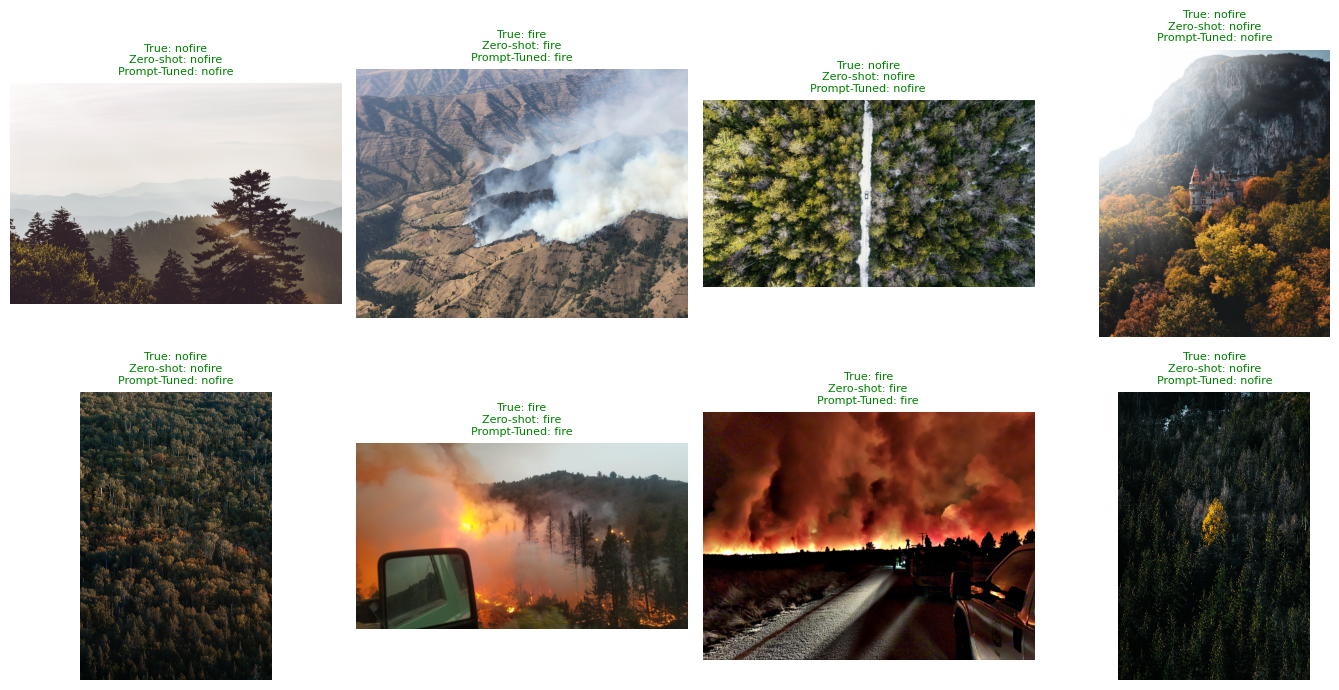

In [40]:
# Figure: Qualitative Examples

fig, axes = plt.subplots(2, 4, figsize=(14,7))

indices = random.sample(range(len(test_paths)), 8)

for ax, idx in zip(axes.flat, indices):

    img = Image.open(test_paths[idx]).convert("RGB")
    ax.imshow(img)

    correct = tuned_preds[idx] == test_labels[idx]
    color = "green" if correct else "red"

    ax.set_title(
        f"True: {test_labels[idx]}\n"
        f"Zero-shot: {zero_shot_preds[idx]}\n"
        f"Prompt-Tuned: {tuned_preds[idx]}",
        fontsize=8,
        color=color
    )

    ax.axis("off")

plt.tight_layout()

plt.savefig(
    "fig_qualitative_examples.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [41]:
from google.colab import files
files.download("fig_qualitative_examples.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Results Summary

In [44]:
{
    "model": "openai/clip-vit-base-patch32",
    "dataset": "elmadafri/the-wildfire-dataset",
    "clip_backbone": "ViT-B/32",
    "classes": [
        "fire",
        "nofire"
    ],
    "train_size": 120,
    "test_size": 80,
    "trainable_parameters": 4096,
    "frozen_parameters": 151277313,
    "epochs": 15,
    "zero_shot_accuracy": 0.9375,
    "prompt_tuned_accuracy": 0.9750,
    "improvement": 0.0375
}

{'model': 'openai/clip-vit-base-patch32',
 'dataset': 'elmadafri/the-wildfire-dataset',
 'clip_backbone': 'ViT-B/32',
 'classes': ['fire', 'nofire'],
 'train_size': 120,
 'test_size': 80,
 'trainable_parameters': 4096,
 'frozen_parameters': 151277313,
 'epochs': 15,
 'zero_shot_accuracy': 0.9375,
 'prompt_tuned_accuracy': 0.975,
 'improvement': 0.0375}